<a href="https://colab.research.google.com/github/taeyeon0102/gdgoc-archive/blob/main/studies/01-basic-AI/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)
#(48999, 28, 28)->(48000, 28, 28, 1)

# 1. 클래스 객체 만들고 첫 합성곱 층 추가
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1)))
# 2. max pooling layer 추가
model.add(keras.layers.MaxPooling2D(2))
# 현재 특성 맵: (14, 14, 32)

# 3. 두 번째 conv-maxpooling layer 만들기
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
# 현재 특성 맵: (7, 7, 64)

# 4. 3d 특성 맵을 펼쳐서 dense layer 통과
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

## 모델 구조 출력
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

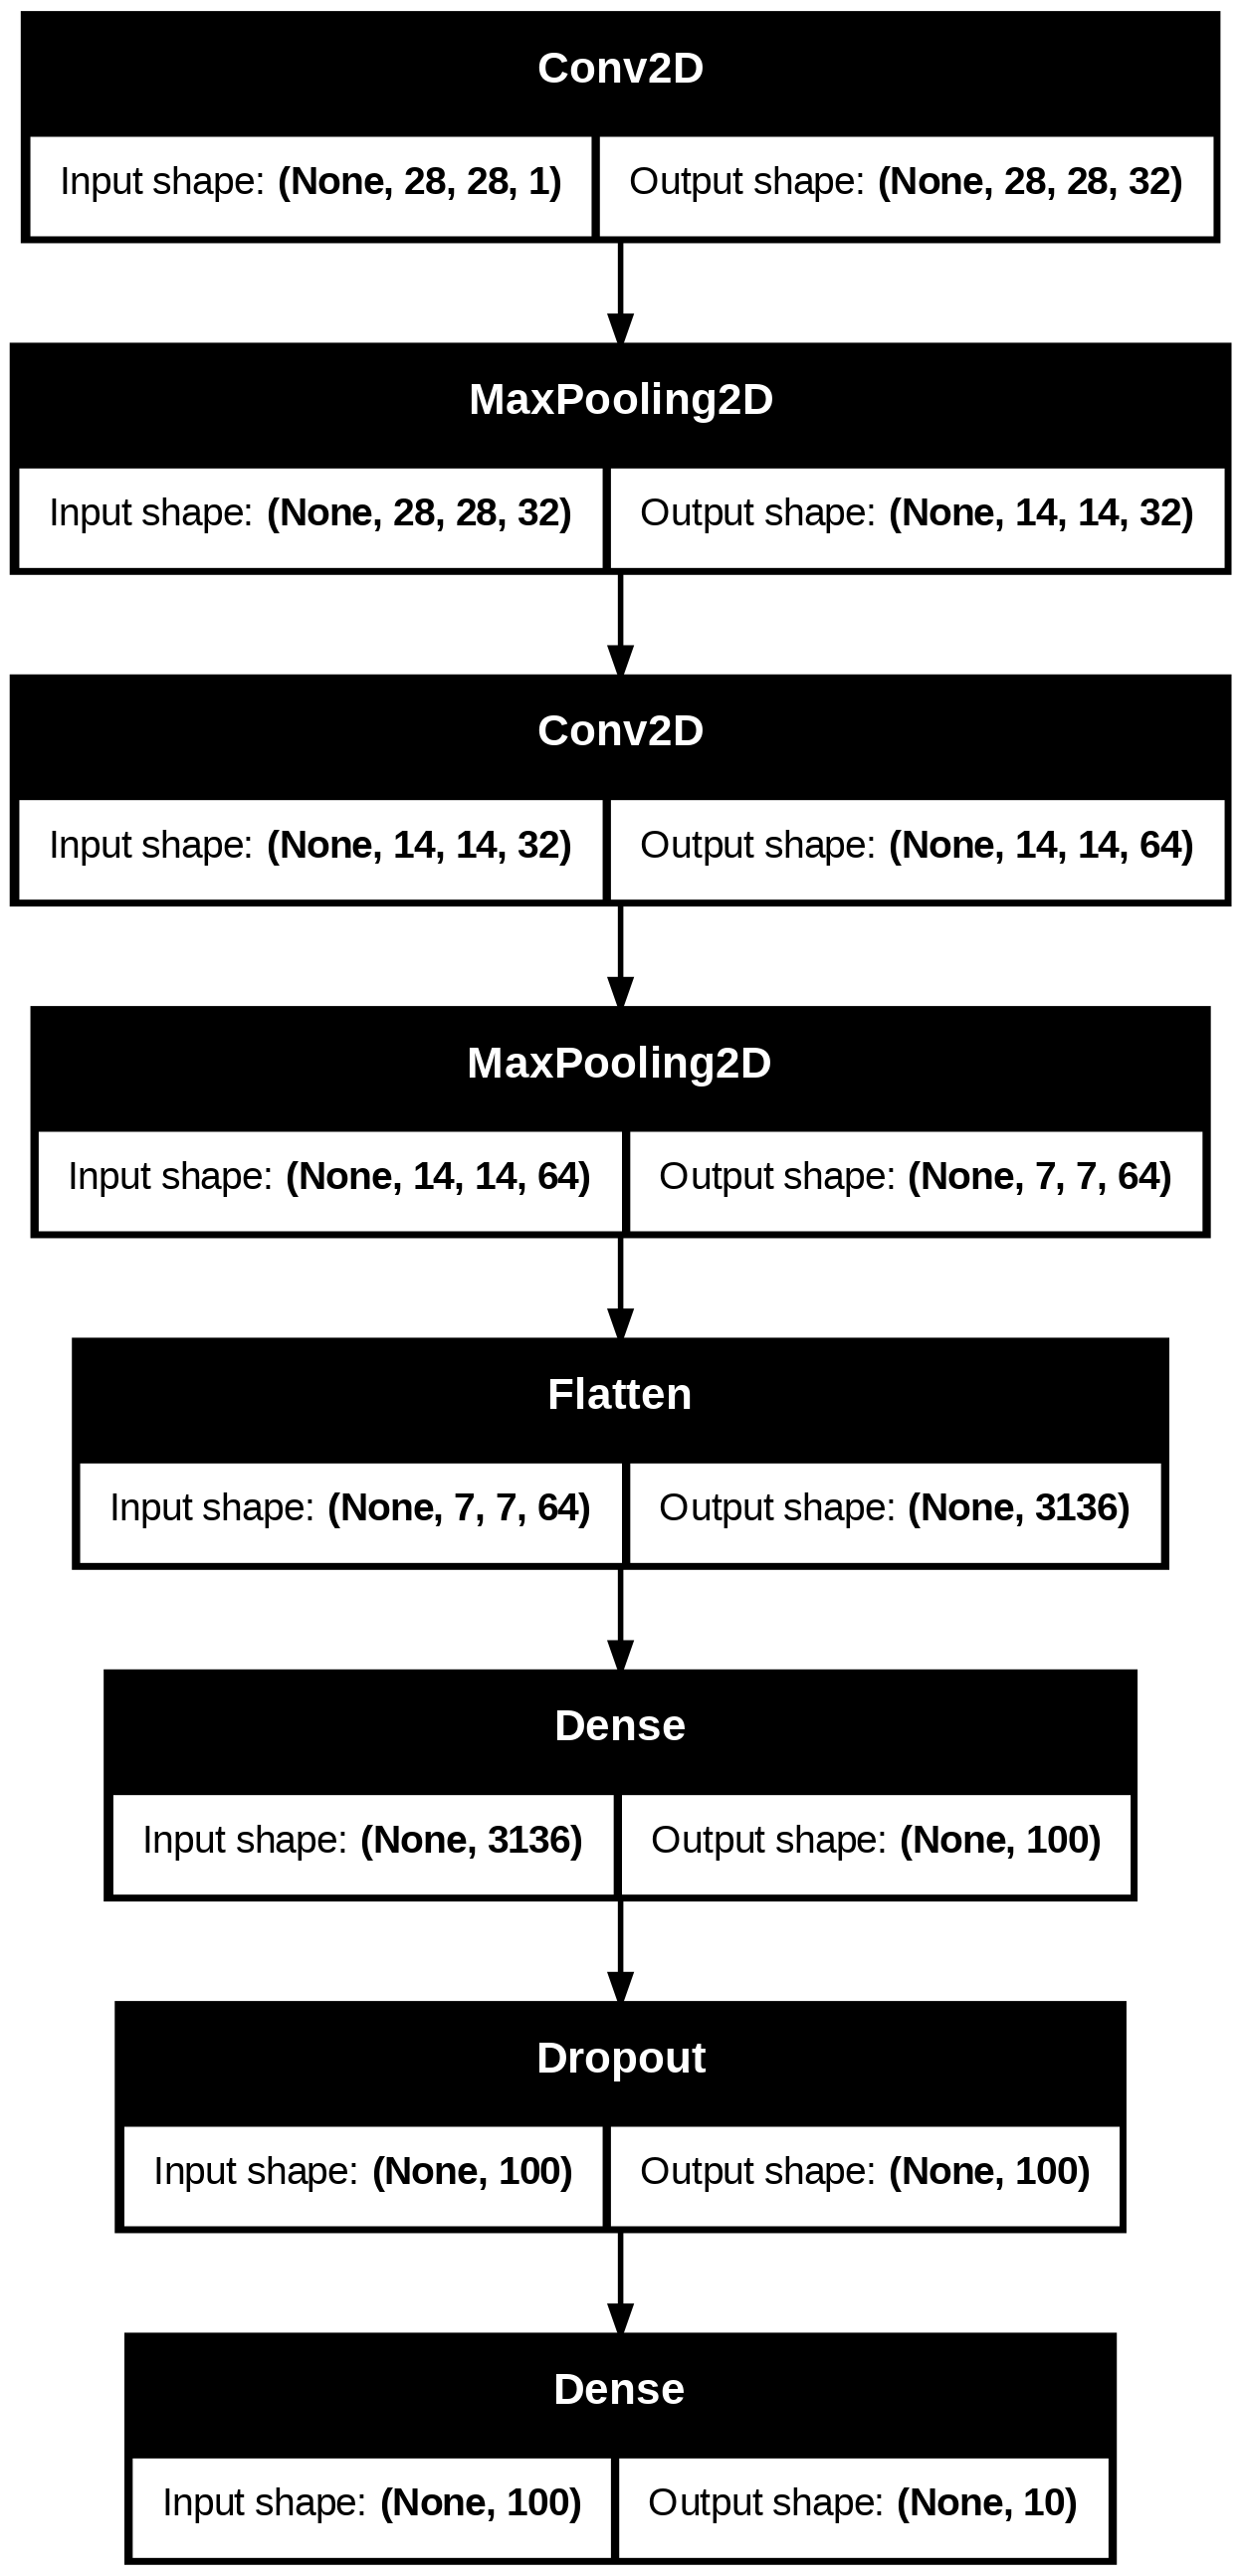

In [ ]:
## 각 layer을 그림으로 출력
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
#####

# 모델 컴파일과 훈련
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics =['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7375 - loss: 0.7300

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7379 - loss: 0.7291 - val_accuracy: 0.8732 - val_loss: 0.3341
Epoch 2/20
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8697 - loss: 0.3720

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8697 - loss: 0.3719 - val_accuracy: 0.8886 - val_loss: 0.3045
Epoch 3/20
1484/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8823 - loss: 0.3235

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8824 - loss: 0.3234 - val_accuracy: 0.9011 - val_loss: 0.2633
Epoch 4/20
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8987 - loss: 0.2824

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8987 - loss: 0.2824 - val_accuracy: 0.9078 - val_loss: 0.2483
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9077 - loss: 0.2558 - val_accuracy: 0.9056 - val_loss: 0.2545
Epoch 6/20
1487/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9124 - loss: 0.2378

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9124 - loss: 0.2378 - val_accuracy: 0.9143 - val_loss: 0.2326
Epoch 7/20
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9215 - loss: 0.2168

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9215 - loss: 0.2168 - val_accuracy: 0.9149 - val_loss: 0.2262
Epoch 8/20
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9245 - loss: 0.2002

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9245 - loss: 0.2002 - val_accuracy: 0.9181 - val_loss: 0.2243
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9280 - loss: 0.1888 - val_accuracy: 0.9115 - val_loss: 0.2446
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9378 - loss: 0.1738 - val_accuracy: 0.9166 - val_loss: 0.2376


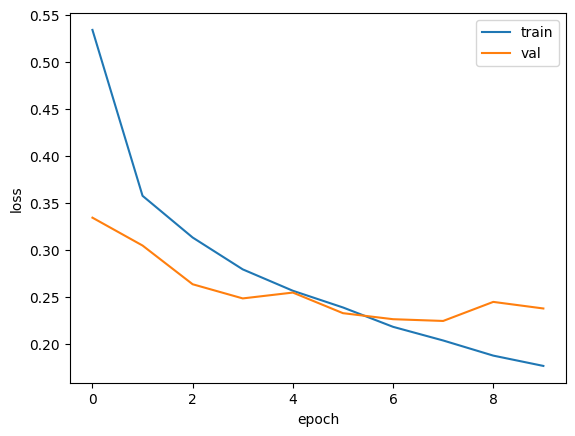

In [ ]:
# 손실 그래프 그리기
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
# 세트에 대한 성능 평가
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9186 - loss: 0.2204


[0.22432665526866913, 0.9180833101272583]

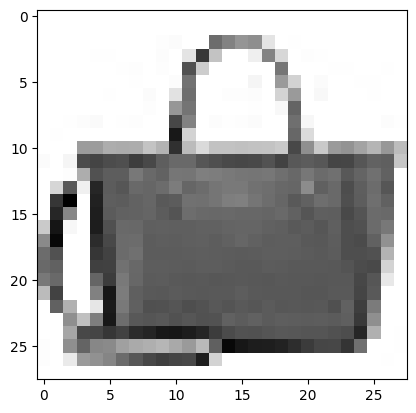

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


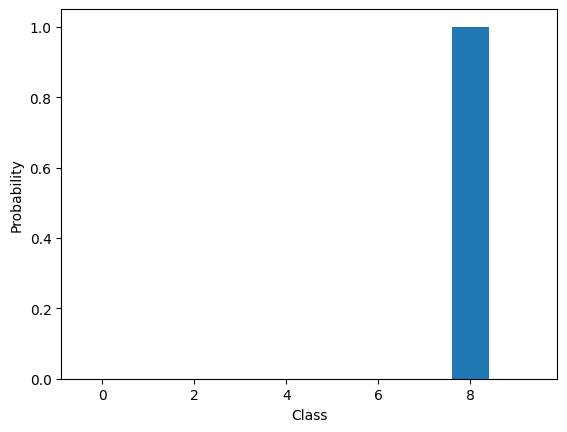

가방


In [ ]:
# 첫 번째 샘플 이미지에 대한 예측값 확인
# (1) 이미지 출력
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()
# (2) 10개의 클래스에 대한 예측 확률 출력
preds = model.predict(val_scaled[0:1])
plt.bar(range(10), preds[0])
plt.xlabel('Class')
plt.ylabel('Probability')
plt.show()

classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌들', '셔츠', '스니커즈', '가방', '앵클부츠']
import numpy as np
print(classes[np.argmax(preds)])


In [ ]:
# 테스트 세트로 검증
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9093 - loss: 0.2493


[0.24453578889369965, 0.9128000140190125]

In [ ]:
### 가중치 시각화

#
from tensorflow import keras
model = keras.models.load_model('best-cnn-model.h5')
model.layers


[<Conv2D name=conv2d_7, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Conv2D name=conv2d_8, built=True>,
 <MaxPooling2D name=max_pooling2d_3, built=True>,
 <Flatten name=flatten_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_3, built=True>]

In [ ]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


-0.014666817 0.24189769


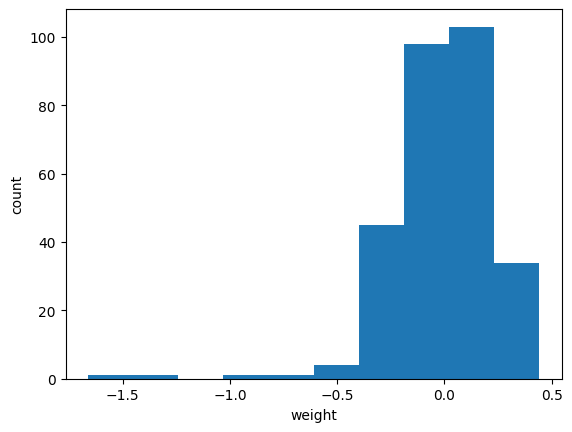

In [ ]:
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())
#히스토그램으로 그리기
import matplotlib.pyplot as plt
plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

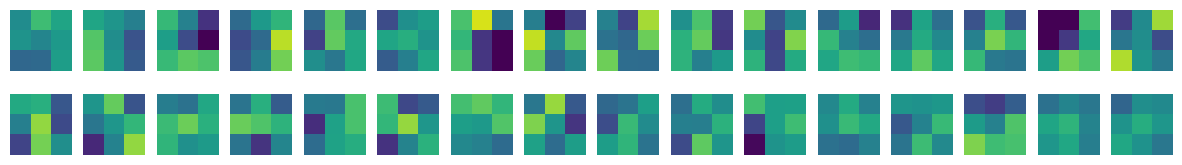

In [ ]:
# 32개 커널 출력
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
  for j in range(16):
    axs[i, j].imshow(conv_weights[:, :, 0, i*16+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')

plt.show()

(3, 3, 1, 32)
-0.0016999622 0.08169382


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


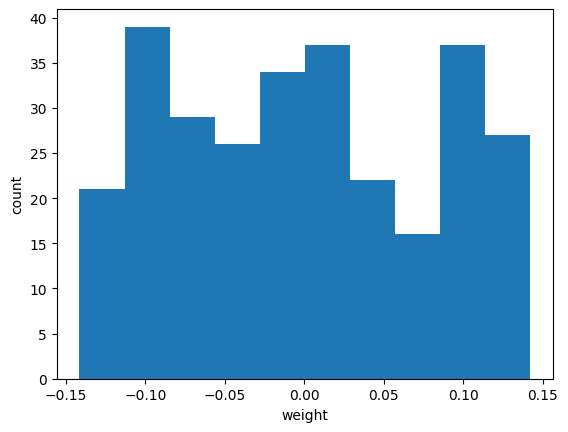

<function matplotlib.pyplot.show(close=None, block=None)>

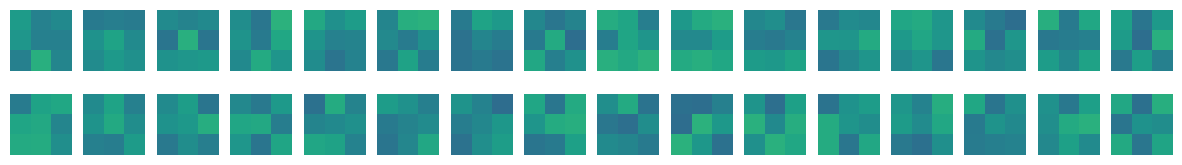

In [ ]:
# 훈련하지 않은 빈 합성곱 신경망
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1)))

no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
  for j in range(16):
    axs[i, j].imshow(no_training_weights[:, :, 0, i*16+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show

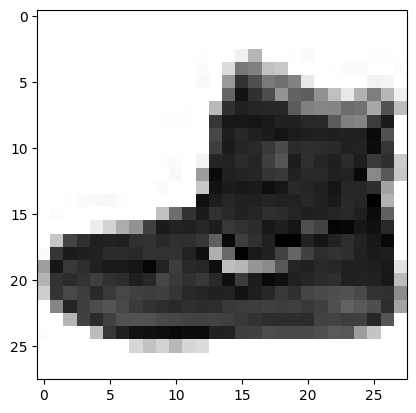

In [ ]:
# 1. keras로 패션 mnist 데이터셋을 읽고 훈련 세트의 첫 번째 샘플 그리기
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
(1, 28, 28, 32)


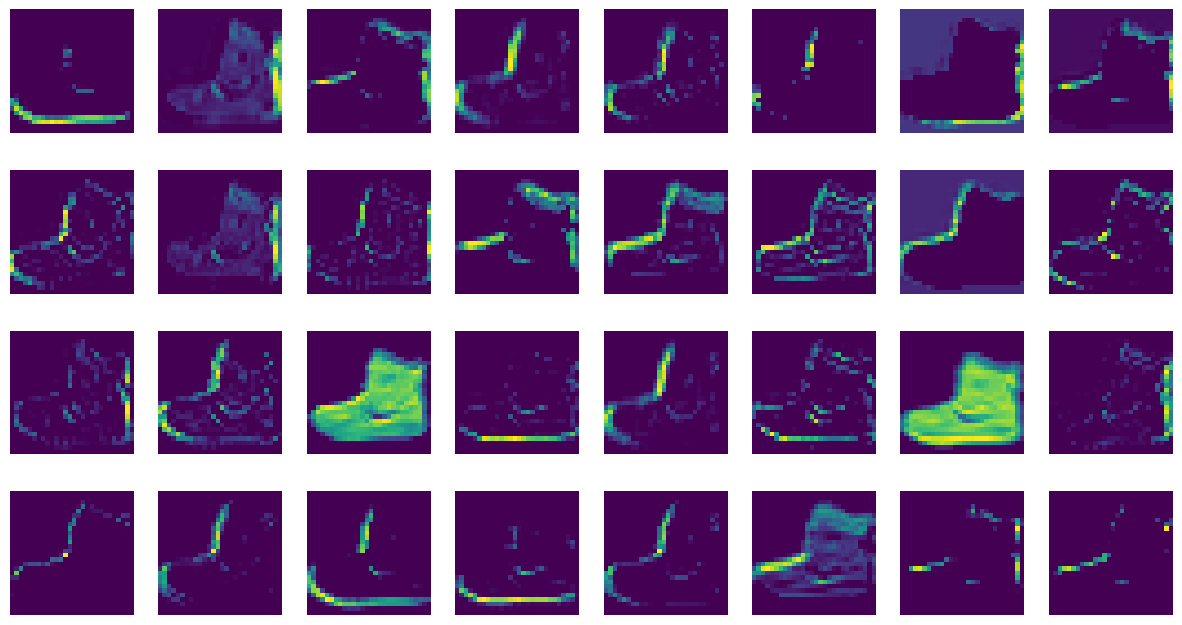

In [ ]:
# 2. 첫 번째 conv layer: 32개 특성 맵 출력
inputs = keras.Input(shape=(28, 28, 1))
outputs = model.layers[0](inputs)
conv_acti = keras.Model(inputs, outputs)

inputs = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(inputs)
print(feature_maps.shape)

fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_maps[0, :, :, i*8+j])
    axs[i, j].axis('off')
plt.show()

In [ ]:
## 3. 두 번째 conv layer : 64개의 특성 맵 출력


# 1. 입력 정의
inputs = keras.Input(shape=(28, 28, 1))

# 2. [중요] 데이터를 앞단 층들부터 차례대로 통과시킵니다.
x = model.layers[0](inputs)  # 첫 번째 Conv
x = model.layers[1](x)       # 첫 번째 Max Pooling
outputs = model.layers[2](x) # 두 번째 Conv (여기가 목표!)

# 3. 모델 생성 (입력 -> 두 번째 Conv 출력)
conv2_acti = keras.Model(inputs, outputs)

# 4. 데이터 준비 및 예측
input_data = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv2_acti.predict(input_data)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
(1, 14, 14, 64)


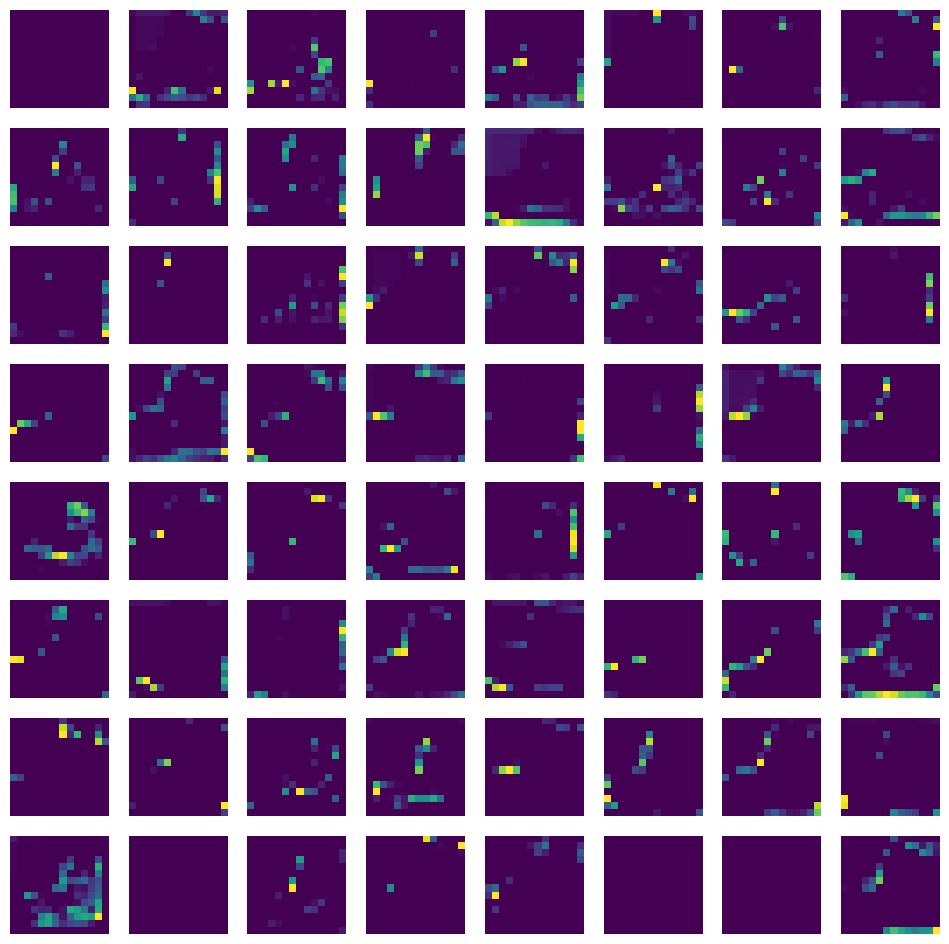

In [ ]:
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
  for j in range(8):
    axs[i, j].imshow(feature_maps[0, :, :, i*8+j])
    axs[i, j].axis('off')
plt.show()